In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns

# Regresion Lineal

In [2]:
from sklearn.linear_model import LinearRegression

In [3]:
data = np.arange(10, 100, step=2)
labels = np.sort(np.random.randint(1000, 100000, len(data)))

## Correlacion entre variables

[Text(0, 0, 'X'), Text(0, 1, 'Y')]

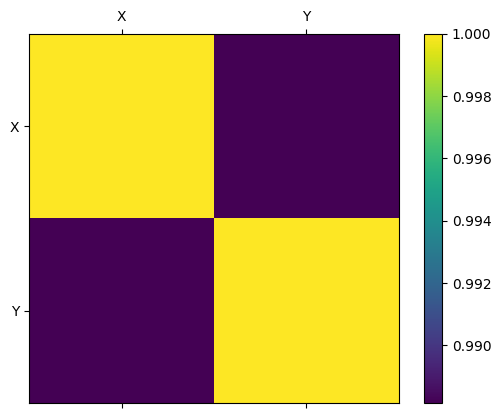

In [4]:
figure = plt.figure()
axes = figure.add_subplot(111)
caxes = axes.matshow(pd.DataFrame({'x':data, 'y':labels}).corr(), interpolation ='nearest')
figure.colorbar(caxes)
axes.xaxis.set_ticks([0,1])
axes.yaxis.set_ticks([0,1])
axes.set_xticklabels(["X", "Y"])
axes.set_yticklabels(["X", "Y"])

In [5]:
x_train,x_test,y_train,y_test=train_test_split(data, labels, test_size=0.2)

In [6]:
model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
model.score(x_test.reshape(-1, 1),y_test)

0.9735841287919774

In [8]:
predicciones = model.predict(x_test.reshape(-1, 1))
predicciones

array([71660.89144465, 76212.17073315, 14769.90033844, 62558.33286766,
       48904.49500216,  1116.06247294, -5710.8564598 , 10218.62104994,
       83039.08966589])

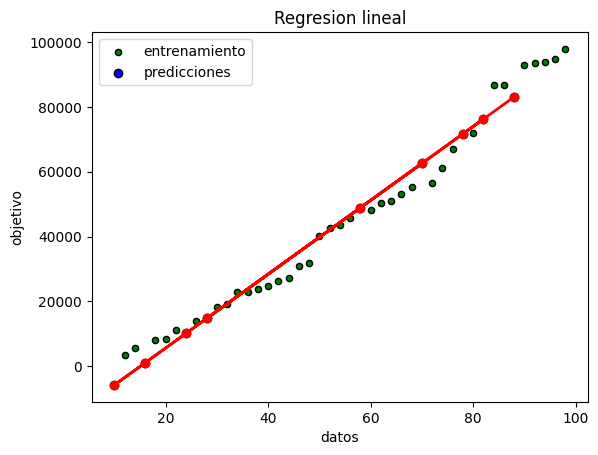

In [9]:
plt.figure()
plt.scatter(x_train, y_train, s=20, edgecolor="black", c="green", label="entrenamiento")
plt.scatter(x_test, predicciones, edgecolor="black", c="blue", label="predicciones",)
plt.plot(x_test,predicciones, 'ro', linestyle='-', linewidth=2)
plt.xlabel("datos")
plt.ylabel("objetivo")
plt.title("Regresion lineal")
plt.legend()
plt.show()

<Axes: >

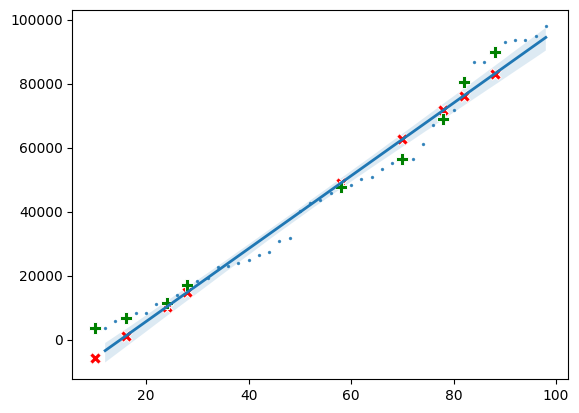

In [11]:
sns.regplot(x=x_train, y=y_train, scatter_kws={'s':2}, line_kws={'linewidth':2})
sns.scatterplot(x=x_test, y=predicciones, color="red", marker="X", s=70)
sns.scatterplot(x=x_test, y=y_test, color="green", marker='P', s=70)

# Y en 3 dimensiones?

In [12]:
datax = np.arange(10, 100, step=2)
datay = np.random.randint(20, 500, len(datax))
labels = np.sort(np.random.randint(1000, 100000, len(datax)))

In [13]:
data_all = pd.DataFrame({'x':datax, 'y':datay})

In [14]:
x_train,x_test,y_train,y_test=train_test_split(data_all, labels, test_size=0.2)

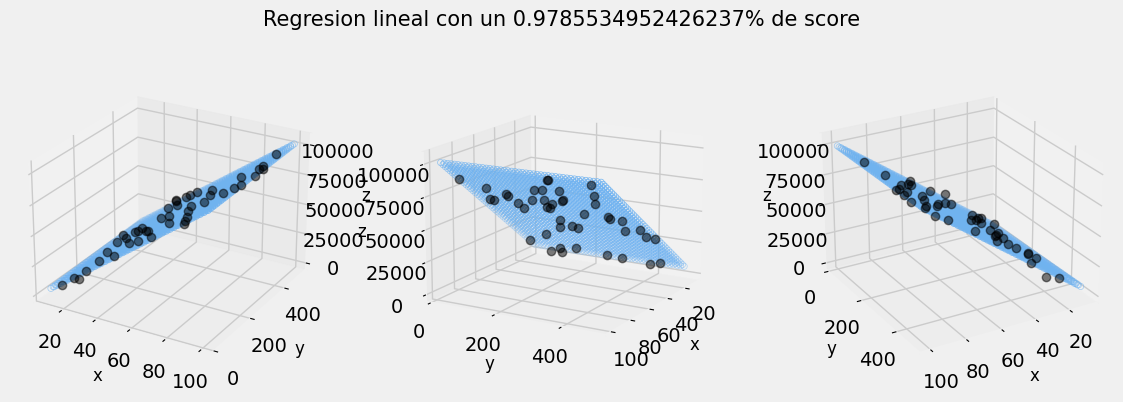

In [17]:
X = data_all[['x', 'y']].values.reshape(-1,2)
Y = labels

x = X[:, 0]
y = X[:, 1]
z = Y

xx_pred = np.linspace(10, 100, 45) 
yy_pred = np.linspace(20, 496, 45)
xx_pred, yy_pred = np.meshgrid(xx_pred, yy_pred)
model_viz = np.array([xx_pred.flatten(), yy_pred.flatten()]).T

ols = LinearRegression()
model = ols.fit(X, Y)
predicted = model.predict(model_viz)

r2 = model.score(X, Y)

plt.style.use('fivethirtyeight')

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

axes = [ax1, ax2, ax3]

for ax in axes:
    ax.plot(x, y, z, color='k', zorder=15, linestyle='none', marker='o', alpha=0.5)
    ax.scatter(xx_pred.flatten(), yy_pred.flatten(), predicted, facecolor=(0,0,0,0), s=20, edgecolor='#70b3f0')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_zlabel('z', fontsize=12)
    ax.locator_params(nbins=4, axis='x')
    ax.locator_params(nbins=5, axis='x')

ax1.view_init(elev=25, azim=-60)
ax2.view_init(elev=15, azim=30)
ax3.view_init(elev=25, azim=60)

fig.suptitle(f'Regresion lineal con un {r2}% de score', fontsize=15, color='k')

fig.tight_layout()

# Con Arbol ML

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

In [19]:
data = np.arange(10, 100, step=2)
labels = np.sort(np.random.randint(1000, 100000, len(data)))

In [20]:
x_train,x_test,y_train,y_test=train_test_split(data, labels, test_size=0.2)

In [21]:
model = DecisionTreeRegressor()
model.fit(x_train.reshape(-1, 1), y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [22]:
model.score(x_test.reshape(-1, 1),y_test)

0.9842854019870865

In [23]:
predicciones = model.predict(x_test.reshape(-1, 1))
predicciones

array([47345., 21185., 27054., 91915., 21185., 55369., 95330., 93192.,
       13478.])

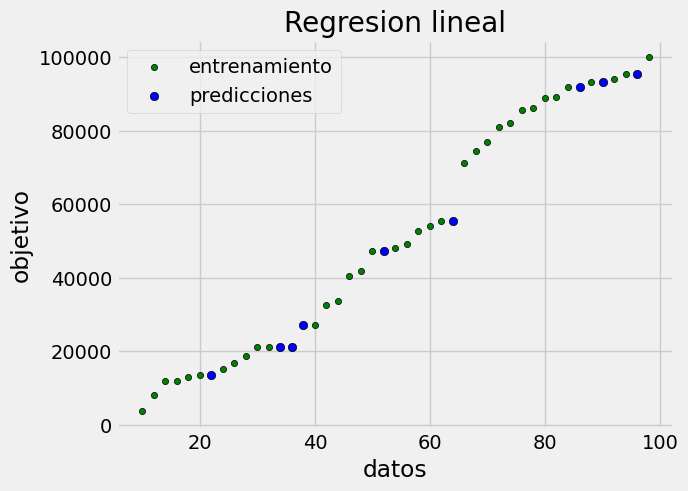

In [24]:
plt.figure()
plt.scatter(x_train, y_train, s=20, edgecolor="black", c="green", label="entrenamiento")
plt.scatter(x_test, predicciones, edgecolor="black", c="blue", label="predicciones",)
#plt.plot(x_test,predicciones, 'ro', linestyle='-', linewidth=2)
plt.xlabel("datos")
plt.ylabel("objetivo")
plt.title("Regresion lineal")
plt.legend()
plt.show()

[Text(0.5590909090909091, 0.9375, 'x[0] <= 61.0\nsquared_error = 835605638.657\nsamples = 36\nvalue = 46916.306'),
 Text(0.2909090909090909, 0.8125, 'x[0] <= 35.0\nsquared_error = 212040271.174\nsamples = 22\nvalue = 27004.091'),
 Text(0.14545454545454545, 0.6875, 'x[0] <= 19.0\nsquared_error = 54731597.056\nsamples = 12\nvalue = 15279.333'),
 Text(0.07272727272727272, 0.5625, 'x[0] <= 13.0\nsquared_error = 13044667.76\nsamples = 5\nvalue = 7985.2'),
 Text(0.03636363636363636, 0.4375, 'x[0] <= 11.0\nsquared_error = 5354596.0\nsamples = 2\nvalue = 4117.0'),
 Text(0.01818181818181818, 0.3125, 'squared_error = 0.0\nsamples = 1\nvalue = 1803.0'),
 Text(0.05454545454545454, 0.3125, 'squared_error = 0.0\nsamples = 1\nvalue = 6431.0'),
 Text(0.10909090909090909, 0.4375, 'x[0] <= 15.0\nsquared_error = 1545858.667\nsamples = 3\nvalue = 10564.0'),
 Text(0.09090909090909091, 0.3125, 'squared_error = 0.0\nsamples = 1\nvalue = 8886.0'),
 Text(0.12727272727272726, 0.3125, 'x[0] <= 17.0\nsquared_erro

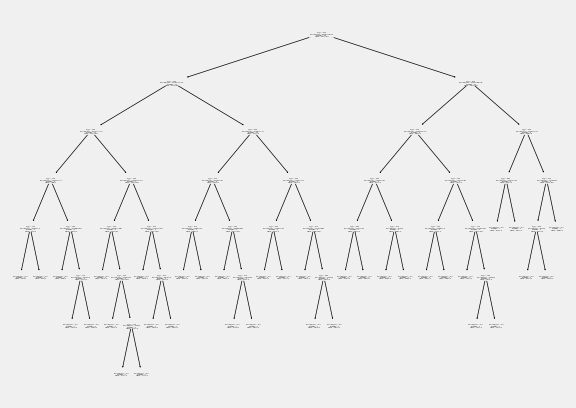

In [31]:
tree.plot_tree(model)

In [32]:
datax = np.arange(10, 100, step=2)
datay = np.random.randint(20, 500, len(datax))
labels = np.sort(np.random.randint(1000, 100000, len(datax)))
data_all = pd.DataFrame({'x':datax, 'y':datay})
x_train,x_test,y_train,y_test=train_test_split(data_all, labels, test_size=0.2)

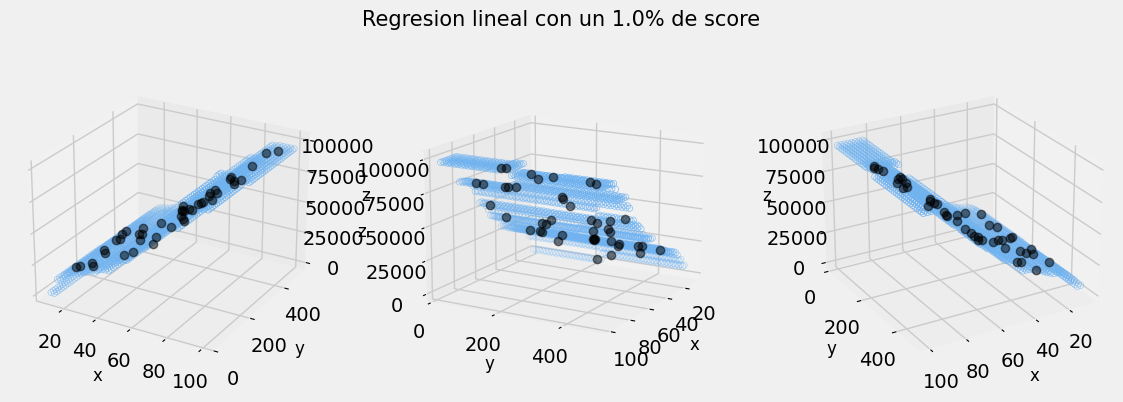

In [33]:
X = data_all[['x', 'y']].values.reshape(-1,2)
Y = labels

x = X[:, 0]
y = X[:, 1]
z = Y

xx_pred = np.linspace(10, 100, 45) 
yy_pred = np.linspace(20, 496, 45)
xx_pred, yy_pred = np.meshgrid(xx_pred, yy_pred)
model_viz = np.array([xx_pred.flatten(), yy_pred.flatten()]).T

ols = DecisionTreeRegressor()
model = ols.fit(X, Y)
predicted = model.predict(model_viz)

r2 = model.score(X, Y)

plt.style.use('fivethirtyeight')

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

axes = [ax1, ax2, ax3]

for ax in axes:
    ax.plot(x, y, z, color='k', zorder=15, linestyle='none', marker='o', alpha=0.5)
    ax.scatter(xx_pred.flatten(), yy_pred.flatten(), predicted, facecolor=(0,0,0,0), s=20, edgecolor='#70b3f0')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_zlabel('z', fontsize=12)
    ax.locator_params(nbins=4, axis='x')
    ax.locator_params(nbins=5, axis='x')

ax1.view_init(elev=25, azim=-60)
ax2.view_init(elev=15, azim=30)
ax3.view_init(elev=25, azim=60)

fig.suptitle(f'Regresion lineal con un {r2}% de score', fontsize=15, color='k')

fig.tight_layout()

# Una tarea especifica

In [34]:
house = pd.read_csv("boston.csv")
house

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [35]:
x_train,x_test,y_train,y_test=train_test_split(house['CRIM'], house["MEDV"], test_size=0.2)

In [36]:
model = LinearRegression()
model.fit(x_train.to_numpy().reshape(-1, 1), y_train)

LinearRegression()

In [37]:
model.score(x_test.to_numpy().reshape(-1, 1), y_test)

0.11843690933549678

In [38]:
predicciones = model.predict(x_test.to_numpy().reshape(-1, 1))

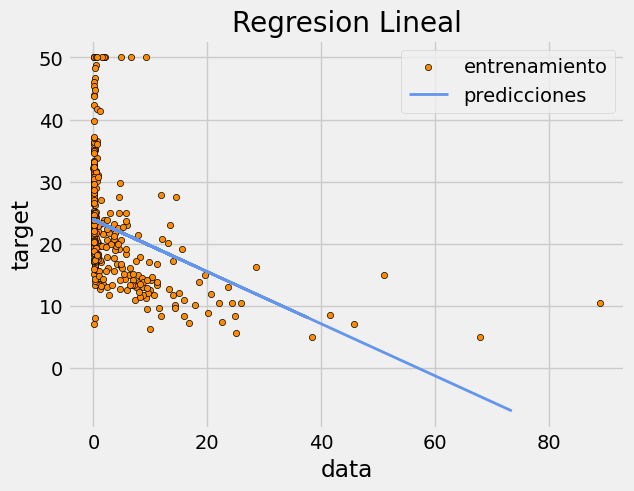

In [39]:
plt.figure()
plt.scatter(x_train.to_numpy().reshape(-1, 1), y_train, s=20, edgecolor="black", c="darkorange", label="entrenamiento")
plt.plot(x_test.to_numpy().reshape(-1, 1), predicciones, color="cornflowerblue", label="predicciones", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Regresion Lineal")
plt.legend()
plt.show()

In [40]:
model = DecisionTreeRegressor()
model.fit(x_train.to_numpy().reshape(-1, 1), y_train)

DecisionTreeRegressor()

In [41]:
model.score(x_test.to_numpy().reshape(-1, 1), y_test)

-0.11032238037575914

In [42]:
predicciones = model.predict(x_test.to_numpy().reshape(-1, 1))

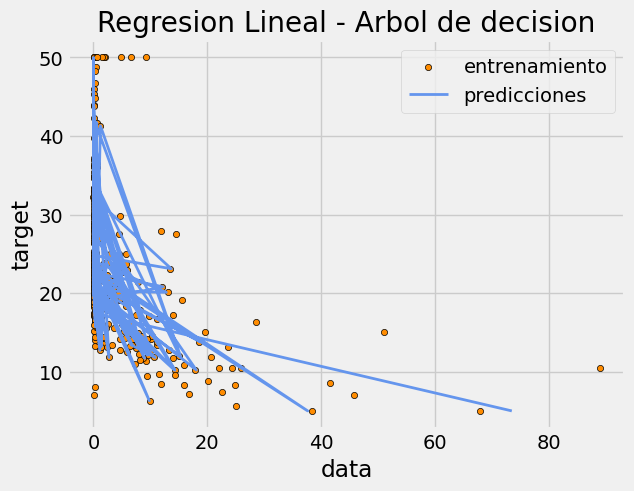

In [43]:
plt.figure()
plt.scatter(x_train.to_numpy().reshape(-1, 1), y_train, s=20, edgecolor="black", c="darkorange", label="entrenamiento")
plt.plot(x_test.to_numpy().reshape(-1, 1), predicciones, color="cornflowerblue", label="predicciones", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Regresion Lineal - Arbol de decision")
plt.legend()
plt.show()

In [44]:
x_train,x_test,y_train,y_test=train_test_split(house.drop(["MEDV"], axis=1), house["MEDV"], test_size=0.2)

In [45]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [46]:
model.score(x_test, y_test)

0.753826204518611

In [47]:
predicciones = model.predict(x_test)

In [48]:
house.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

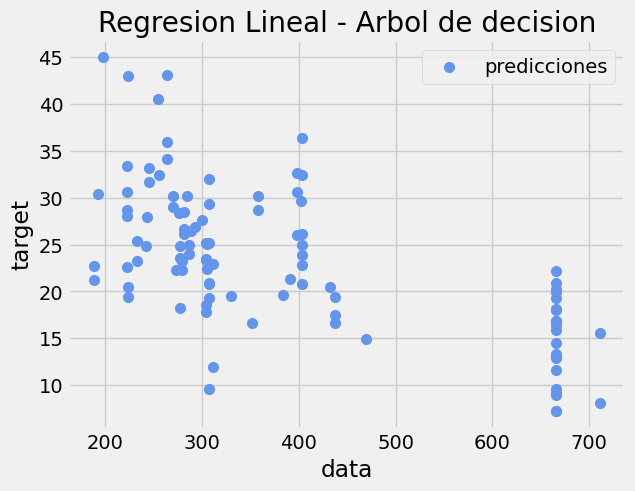

In [49]:
plt.figure()
plt.scatter(x_test["TAX"], predicciones, color="cornflowerblue", label="predicciones", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Regresion Lineal - Arbol de decision")
plt.legend()
plt.show()

[Text(0, 0, 'CRIM'),
 Text(0, 1, 'ZN'),
 Text(0, 2, 'INDUS'),
 Text(0, 3, 'CHAS'),
 Text(0, 4, 'NOX'),
 Text(0, 5, 'RM'),
 Text(0, 6, 'AGE'),
 Text(0, 7, 'DIS'),
 Text(0, 8, 'RAD'),
 Text(0, 9, 'TAX'),
 Text(0, 10, 'PTRATIO'),
 Text(0, 11, 'B'),
 Text(0, 12, 'LSTAT'),
 Text(0, 13, 'MEDV')]

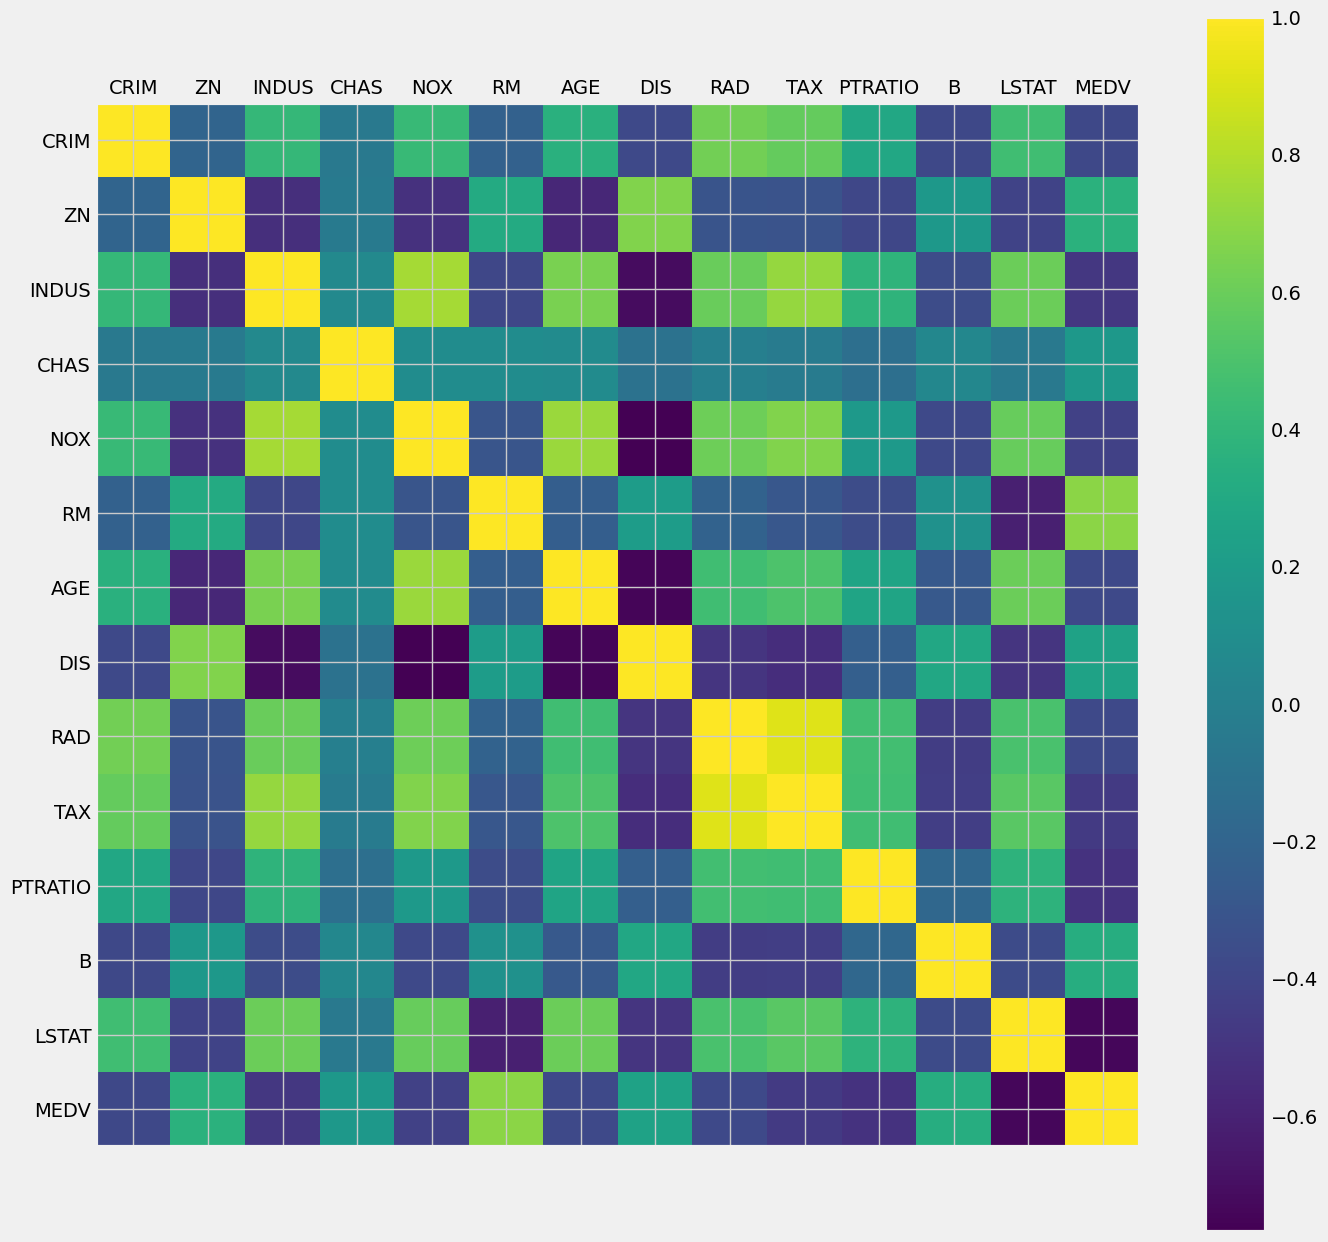

In [50]:
figure = plt.figure(figsize=(15,15))
axes = figure.add_subplot(111)
caxes = axes.matshow(house.corr(), interpolation ='nearest')
figure.colorbar(caxes)
axes.xaxis.set_ticks(np.arange(0,len(house.columns)))
axes.yaxis.set_ticks(np.arange(0,len(house.columns)))
axes.set_xticklabels(['']+house.columns)
axes.set_yticklabels(['']+house.columns)

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
x_train,x_test,y_train,y_test=train_test_split(house.drop(["MEDV"], axis=1), house["MEDV"], test_size=0.2)

In [53]:
model = RandomForestRegressor(250)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=250)

In [54]:
model.score(x_test, y_test)

0.8305981524572387

In [55]:
predicciones = model.predict(x_test)

In [56]:
house.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

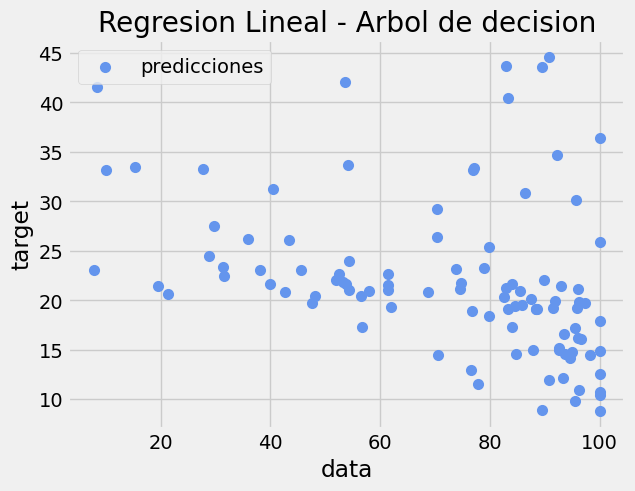

In [57]:
plt.figure()
plt.scatter(x_test["AGE"], predicciones, color="cornflowerblue", label="predicciones", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Regresion Lineal - Arbol de decision")
plt.legend()
plt.show()